# Multiple Linear Regression
# Bike Sharing Demand
### Problem Statement:
##### A bike-sharing provider EBikes has recently suffered considerable dips in their revenues
#### They have contracted a consulting company to understand the factors on which the demand for these shared bikes depends. ####Specifically, they want to understand the factors affecting the demand for these shared bikes in the American market
#### The company wants to know:__Which variables are significant in predicting the demand for shared bikes
#### How well those variables describe the bike demands
#### You are required to model the demand for shared bikes with the available independent variables
#### It will be used by the management to understand how exactly the demands vary with different features
#### They can accordingly manipulate the business strategy to meet the demand levels and meet the customers expectations
#### Further, the model will be a good way for management to understand the demand dynamics of a new market###

# Step 1: Reading and Understanding the Data

In [ ]:
# Supress Warnings
import warnings
warnings.filterwarnings('ignore')

In [ ]:
#importing libraries

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor

import sklearn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.linear_model import LinearRegression
from sklearn.feature_selection import RFE
from sklearn.metrics import r2_score

from math import sqrt

In [ ]:
## reading data
bike_data = pd.read_csv('https://raw.githubusercontent.com/hari9255/Task-1/a72ab52baaf1df0d3a9b44e5c763cbdfdf3f97a2/day.csv')
bike_data.head()

,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,01-01-2018,1,0,1,0,6,0,2,14.110847,18.18125,80.5833,10.749882,331,654,985
1,2,02-01-2018,1,0,1,0,0,0,2,14.902598,17.68695,69.6087,16.652113,131,670,801
2,3,03-01-2018,1,0,1,0,1,1,1,8.050924,9.47025,43.7273,16.636703,120,1229,1349
3,4,04-01-2018,1,0,1,0,2,1,1,8.200000,10.60610,59.0435,10.739832,108,1454,1562
4,5,05-01-2018,1,0,1,0,3,1,1,9.305237,11.46350,43.6957,12.522300,82,1518,1600


In [ ]:
bike_data.shape

(730, 16)

In [ ]:
bike_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 730 entries, 0 to 729
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     730 non-null    int64  
 1   dteday      730 non-null    object 
 2   season      730 non-null    int64  
 3   yr          730 non-null    int64  
 4   mnth        730 non-null    int64  
 5   holiday     730 non-null    int64  
 6   weekday     730 non-null    int64  
 7   workingday  730 non-null    int64  
 8   weathersit  730 non-null    int64  
 9   temp        730 non-null    float64
 10  atemp       730 non-null    float64
 11  hum         730 non-null    float64
 12  windspeed   730 non-null    float64
 13  casual      730 non-null    int64  
 14  registered  730 non-null    int64  
 15  cnt         730 non-null    int64  
dtypes: float64(4), int64(11), object(1)
memory usage: 91.4+ KB


In [ ]:
bike_data.describe()

,instant,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
count,730.000000,730.000000,730.000000,730.000000,730.000000,730.000000,730.000000,730.000000,730.000000,730.000000,730.000000,730.000000,730.000000,730.000000,730.000000
mean,365.500000,2.498630,0.500000,6.526027,0.028767,2.997260,0.683562,1.394521,20.319259,23.726322,62.765175,12.763620,849.249315,3658.757534,4508.006849
std,210.877136,1.110184,0.500343,3.450215,0.167266,2.006161,0.465405,0.544807,7.506729,8.150308,14.237589,5.195841,686.479875,1559.758728,1936.011647
min,1.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000,2.424346,3.953480,0.000000,1.500244,2.000000,20.000000,22.000000
25%,183.250000,2.000000,0.000000,4.000000,0.000000,1.000000,0.000000,1.000000,13.811885,16.889713,52.000000,9.041650,316.250000,2502.250000,3169.750000
50%,365.500000,3.000000,0.500000,7.000000,0.000000,3.000000,1.000000,1.000000,20.465826,24.368225,62.625000,12.125325,717.000000,3664.500000,4548.500000
75%,547.750000,3.000000,1.000000,10.000000,0.000000,5.000000,1.000000,2.000000,26.880615,30.445775,72.989575,15.625589,1096.500000,4783.250000,5966.000000
max,730.000000,4.000000,1.000000,12.000000,1.000000,6.000000,1.000000,3.000000,35.328347,42.044800,97.250000,34.000021,3410.000000,6946.000000,8714.000000


#### Since the difference between mean and median is not much , we can conclude that data has no outliers

## Step 2: Visualising the Data

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

#### Visualising Numeric Variables

#### Let's make a pairplot of all the numeric variables

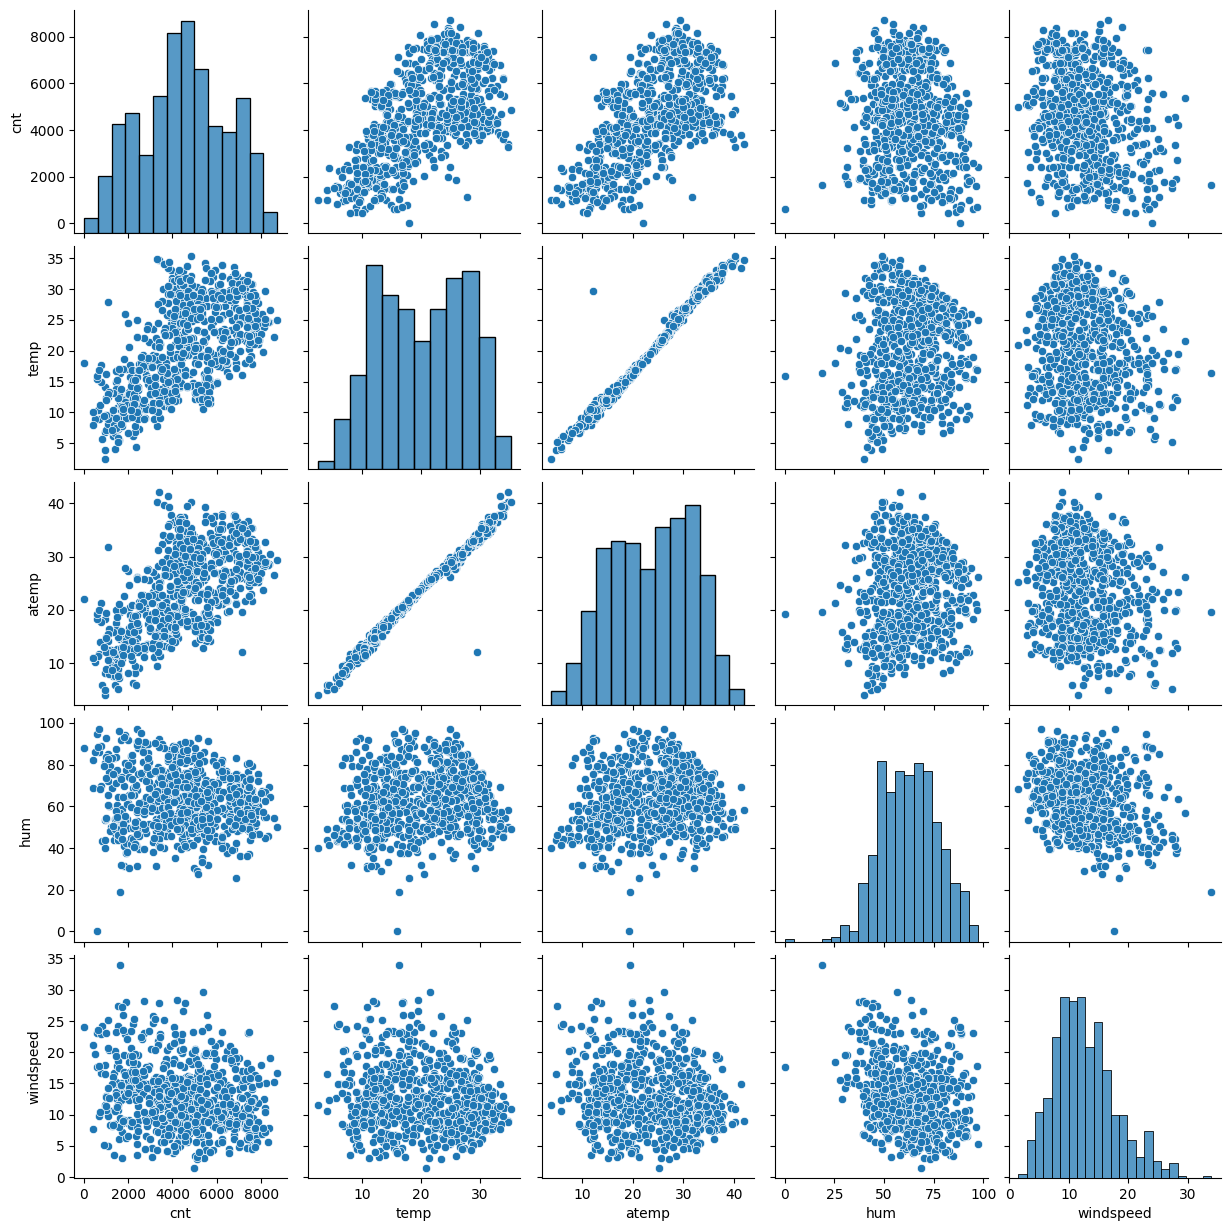

In [ ]:
sns.pairplot(data=bike_data,vars=['cnt', 'temp', 'atemp', 'hum','windspeed'])
plt.show()

### Inference:
### Looks like the temp and atemp has the highest corelation with the target variable cnt
### temp and atemp are highly co-related with each other

### Visualising Categorical Variables

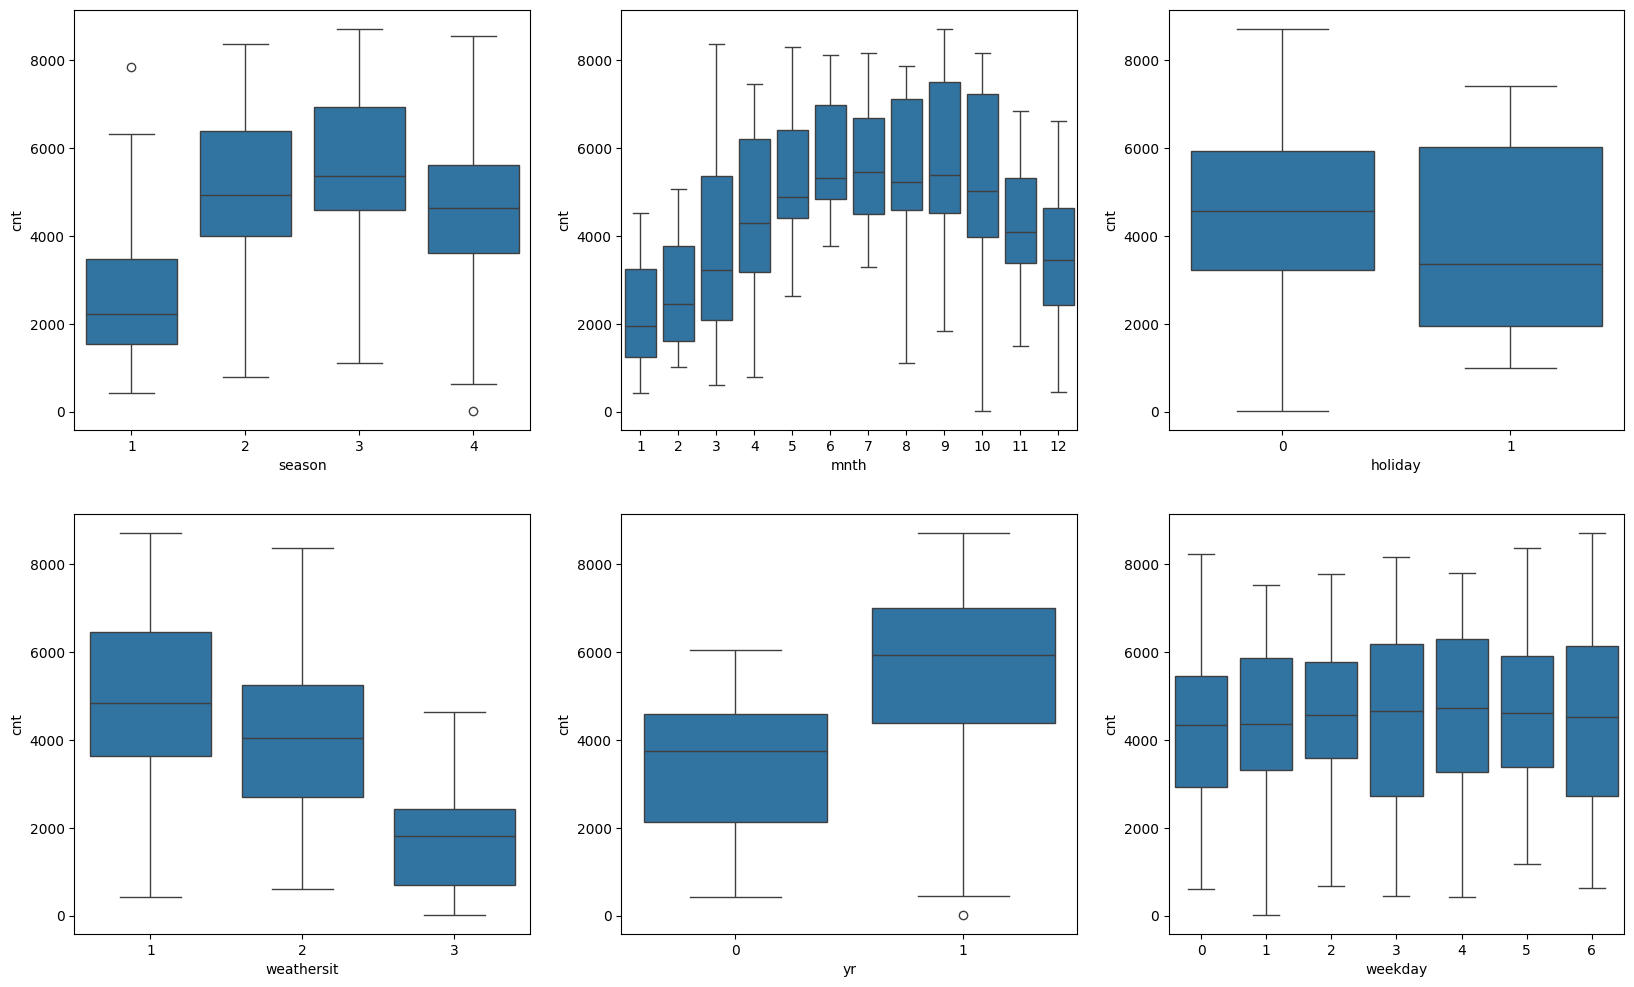

In [ ]:
plt.figure(figsize=(20, 12))
plt.subplot(2,3,1)
sns.boxplot(x = 'season', y = 'cnt', data = bike_data)
plt.subplot(2,3,2)
sns.boxplot(x = 'mnth', y = 'cnt', data = bike_data)
plt.subplot(2,3,3)
sns.boxplot(x = 'holiday', y = 'cnt', data = bike_data)
plt.subplot(2,3,4)
sns.boxplot(x = 'weathersit', y = 'cnt', data = bike_data)
plt.subplot(2,3,5)
sns.boxplot(x = 'yr', y = 'cnt', data = bike_data)
plt.subplot(2,3,6)
sns.boxplot(x = 'weekday', y = 'cnt', data = bike_data)
plt.show()

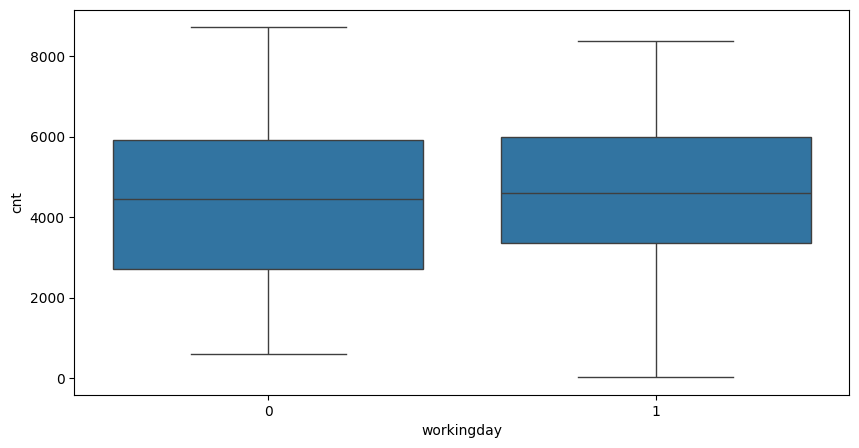

In [ ]:
plt.figure(figsize = (10, 5))
sns.boxplot(x = 'workingday', y = 'cnt', data = bike_data)
plt.show()

## Inferences
#### The count of bike sharing is least for spring and highest in fall
#### The number of bike shares increased in 2019
#### The cnt has zero values for weather situation - 'Heavy Rain + Ice Pallets + Thunderstorm + Mist, Snow + Fog' & highest in clear weathersit
#### The cnt values increases in summer months & highest in September
#### The cnt values ars less during holidays

# Step 3: Data Preparation

In [ ]:
## dropping columns that are irrelevant for the model -
bike_data.drop(['instant','dteday','casual','registered'],axis = 1,inplace = True)
bike_data.head()

,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,cnt
0,1,0,1,0,6,0,2,14.110847,18.18125,80.5833,10.749882,985
1,1,0,1,0,0,0,2,14.902598,17.68695,69.6087,16.652113,801
2,1,0,1,0,1,1,1,8.050924,9.47025,43.7273,16.636703,1349
3,1,0,1,0,2,1,1,8.200000,10.60610,59.0435,10.739832,1562
4,1,0,1,0,3,1,1,9.305237,11.46350,43.6957,12.522300,1600


In [ ]:
### Converting some numeric values to categorical data
import calendar
bike_data['mnth'] = bike_data['mnth'].apply(lambda x: calendar.month_abbr[x])

In [ ]:
bike_data['mnth']

,mnth
0,Jan
1,Jan
2,Jan
3,Jan
4,Jan
...,...
725,Dec
726,Dec
727,Dec
728,Dec


In [ ]:
## maping seasons
bike_data.season = bike_data.season.map({1: 'Spring',2:'Summer',3:'Fall',4:'Winter'})

In [ ]:
## mapping weathersit
bike_data.weathersit = bike_data.weathersit.map({1:'Clear',2:'Mist & Cloudy',
                                             3:'Light Snow & Rain',4:'Heavy Snow & Rain'})

In [ ]:
bike_data.weekday = bike_data.weekday.map({0:"Sunday",1:"Monday",2:"Tuesday",3:"Wednesday",4:"Thrusday",5:"Friday",6:"Saturday"})

In [ ]:
# Check the dataframe now

bike_data.head()

,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,cnt
0,Spring,0,Jan,0,Saturday,0,Mist & Cloudy,14.110847,18.18125,80.5833,10.749882,985
1,Spring,0,Jan,0,Sunday,0,Mist & Cloudy,14.902598,17.68695,69.6087,16.652113,801
2,Spring,0,Jan,0,Monday,1,Clear,8.050924,9.47025,43.7273,16.636703,1349
3,Spring,0,Jan,0,Tuesday,1,Clear,8.200000,10.60610,59.0435,10.739832,1562
4,Spring,0,Jan,0,Wednesday,1,Clear,9.305237,11.46350,43.6957,12.522300,1600


## Feature Engineering

In [ ]:
#dummy variable
dummy= bike_data[['season','mnth','weekday','weathersit']]
dummy_cols = pd.get_dummies(dummy,dtype=float)

In [ ]:
dummy_cols.head()

,season_Fall,season_Spring,season_Summer,season_Winter,mnth_Apr,mnth_Aug,mnth_Dec,mnth_Feb,mnth_Jan,mnth_Jul,...,weekday_Friday,weekday_Monday,weekday_Saturday,weekday_Sunday,weekday_Thrusday,weekday_Tuesday,weekday_Wednesday,weathersit_Clear,weathersit_Light Snow & Rain,weathersit_Mist & Cloudy
0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
1,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0
2,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
3,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0
4,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0


In [ ]:
bike_data = pd.concat([bike_data,dummy_cols],axis=1)

In [ ]:
bike_data.head()

,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,...,weekday_Friday,weekday_Monday,weekday_Saturday,weekday_Sunday,weekday_Thrusday,weekday_Tuesday,weekday_Wednesday,weathersit_Clear,weathersit_Light Snow & Rain,weathersit_Mist & Cloudy
0,Spring,0,Jan,0,Saturday,0,Mist & Cloudy,14.110847,18.18125,80.5833,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
1,Spring,0,Jan,0,Sunday,0,Mist & Cloudy,14.902598,17.68695,69.6087,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0
2,Spring,0,Jan,0,Monday,1,Clear,8.050924,9.47025,43.7273,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
3,Spring,0,Jan,0,Tuesday,1,Clear,8.200000,10.60610,59.0435,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0
4,Spring,0,Jan,0,Wednesday,1,Clear,9.305237,11.46350,43.6957,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0


In [ ]:
bike_data.drop(['season','mnth','weekday','weathersit'],axis=1,inplace=True)

In [ ]:
bike_data

,yr,holiday,workingday,temp,atemp,hum,windspeed,cnt,season_Fall,season_Spring,...,weekday_Friday,weekday_Monday,weekday_Saturday,weekday_Sunday,weekday_Thrusday,weekday_Tuesday,weekday_Wednesday,weathersit_Clear,weathersit_Light Snow & Rain,weathersit_Mist & Cloudy
0,0,0,0,14.110847,18.18125,80.5833,10.749882,985,0.0,1.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
1,0,0,0,14.902598,17.68695,69.6087,16.652113,801,0.0,1.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0
2,0,0,1,8.050924,9.47025,43.7273,16.636703,1349,0.0,1.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
3,0,0,1,8.200000,10.60610,59.0435,10.739832,1562,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0
4,0,0,1,9.305237,11.46350,43.6957,12.522300,1600,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
725,1,0,1,10.420847,11.33210,65.2917,23.458911,2114,0.0,1.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
726,1,0,1,10.386653,12.75230,59.0000,10.416557,3095,0.0,1.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
727,1,0,0,10.386653,12.12000,75.2917,8.333661,1341,0.0,1.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
728,1,0,0,10.489153,11.58500,48.3333,23.500518,1796,0.0,1.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0


In [ ]:
from sklearn.model_selection import train_test_split
train, test = train_test_split(bike_data,train_size=0.8,random_state =3)

In [ ]:
# Rescaling the continuous
cont_features = ['temp','atemp','hum','windspeed','cnt']
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
train[cont_features] = scaler.fit_transform(train[cont_features])

In [ ]:
train

,yr,holiday,workingday,temp,atemp,hum,windspeed,cnt,season_Fall,season_Spring,...,weekday_Friday,weekday_Monday,weekday_Saturday,weekday_Sunday,weekday_Thrusday,weekday_Tuesday,weekday_Wednesday,weathersit_Clear,weathersit_Light Snow & Rain,weathersit_Mist & Cloudy
362,0,0,1,0.239486,0.242604,0.590403,0.200012,0.276231,0.0,1.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0
264,0,0,1,0.720476,0.624674,0.927592,0.217975,0.549126,1.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
134,0,0,0,0.637147,0.599783,0.891602,0.269213,0.521284,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0
460,1,0,1,0.435679,0.409145,0.387746,0.573104,0.740681,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
448,1,0,0,0.478927,0.470473,0.905741,0.408978,0.572250,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
659,1,0,1,0.542215,0.530137,0.584404,0.121820,0.809480,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
256,0,0,1,0.777436,0.719101,0.716795,0.298736,0.547975,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0
643,1,0,0,0.626600,0.603092,0.682948,0.506386,0.913829,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
249,0,0,1,0.683559,0.610585,0.943016,0.153852,0.227105,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0


<Axes: >

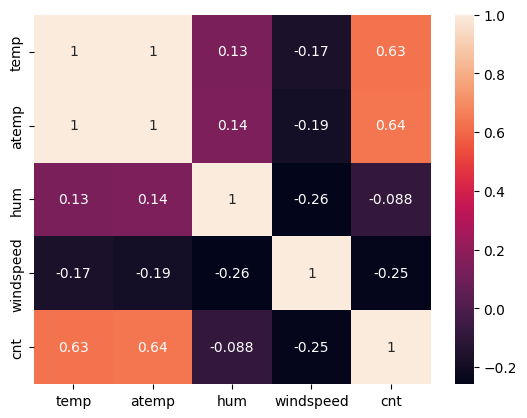

In [ ]:
sns.heatmap(train[cont_features].corr(),annot=True)

In [ ]:
train.drop(['temp'],axis=1,inplace=True)
test.drop(['temp'],axis=1,inplace=True)

## Model Building

In [ ]:
y_train = train.pop('cnt')
X_train = train

In [ ]:
y_test = test.pop('cnt')
X_test = test

In [ ]:
X_train.shape

(584, 32)

In [ ]:
from sklearn.linear_model import LinearRegression
reg = LinearRegression().fit(X_train, y_train)

In [ ]:
reg.score(X_train, y_train)

0.8530206729337533

In [ ]:
reg.score(X_test, y_test)

-5.474291415548295

In [ ]:
# Open a file and use dump()
import pickle
with open('model.pkl', 'wb') as file:
    # A new file will be created
    pickle.dump(reg, file)

In [ ]:
# call pickle file
import pickle
with open('model.pkl', 'rb') as file:
    model = pickle.load(file)

In [ ]:
train.head()

In [ ]:
from sklearn.feature_selection import RFE
lr = LinearRegression()
rfe = RFE(lr, n_features_to_select=12)
rfe = rfe.fit(X_train, y_train)

In [ ]:
rfe.support_

array([False,  True,  True, False, False, False,  True,  True,  True,
        True, False, False, False, False, False, False, False, False,
       False, False, False, False,  True, False,  True,  True,  True,
        True,  True, False, False, False])

In [ ]:
rfe.ranking_

array([19,  1,  1, 18, 20, 21,  1,  1,  1,  1,  9, 12,  4,  6,  5, 11, 14,
        8, 13,  3,  7, 10,  1,  2,  1,  1,  1,  1,  1, 15, 17, 16])

In [ ]:
col = X_train.columns[rfe.support_]

In [ ]:
col

Index(['holiday', 'workingday', 'season_Fall', 'season_Spring',
       'season_Summer', 'season_Winter', 'weekday_Friday', 'weekday_Saturday',
       'weekday_Sunday', 'weekday_Thrusday', 'weekday_Tuesday',
       'weekday_Wednesday'],
      dtype='object')

In [ ]:
X_train = X_train[col]

In [ ]:
X_train.head()

In [ ]:
reg = LinearRegression().fit(X_train, y_train)

In [ ]:
reg.score(X_train, y_train)

0.35791552528984605

In [ ]:
import statsmodels.api as sm
#from statsmodels.stats.outliers_influence import variance_inflation_factor

In [ ]:
X_train = sm.add_constant(X_train)

In [ ]:
X_train

,const,yr,holiday,workingday,atemp,hum,windspeed,season_Fall,season_Spring,season_Summer,...,weekday_Friday,weekday_Monday,weekday_Saturday,weekday_Sunday,weekday_Thrusday,weekday_Tuesday,weekday_Wednesday,weathersit_Clear,weathersit_Light Snow & Rain,weathersit_Mist & Cloudy
362,1.0,0,0,1,0.242604,0.590403,0.200012,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0
264,1.0,0,0,1,0.624674,0.927592,0.217975,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
134,1.0,0,0,0,0.599783,0.891602,0.269213,0.0,0.0,1.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0
460,1.0,1,0,1,0.409145,0.387746,0.573104,0.0,0.0,1.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
448,1.0,1,0,0,0.470473,0.905741,0.408978,0.0,0.0,1.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
659,1.0,1,0,1,0.530137,0.584404,0.121820,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
256,1.0,0,0,1,0.719101,0.716795,0.298736,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0
643,1.0,1,0,0,0.603092,0.682948,0.506386,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
249,1.0,0,0,1,0.610585,0.943016,0.153852,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0


In [ ]:
ols_model = sm.OLS(y_train,X_train).fit()

In [ ]:
import pickle

# Open the pkl file in binary mode
with open('/content/regression_model.pkl', 'wb') as f:
    # Load the data from the file
    pickle.dump(ols_model, f)

# Close the file
f.close()

In [ ]:
print(ols_model.summary())

                            OLS Regression Results                            
Dep. Variable:                    cnt   R-squared:                       0.853
Model:                            OLS   Adj. R-squared:                  0.846
Method:                 Least Squares   F-statistic:                     119.5
Date:                Fri, 21 Jun 2024   Prob (F-statistic):          1.22e-211
Time:                        07:31:40   Log-Likelihood:                 606.24
No. Observations:                 584   AIC:                            -1156.
Df Residuals:                     556   BIC:                            -1034.
Df Model:                          27                                         
Covariance Type:            nonrobust                                         
                                   coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------------
const           